Análise do Boston Housing Dataset com Álgebra Linear e Estatística em Python
Boston Housing Dataset Analysis using Linear Algebra and Statistics in Python

Português

Este projeto explora o Boston Housing Dataset utilizando ferramentas de Python, álgebra linear e estatística exploratória para investigar relações entre características socioeconômicas e o preço de imóveis.

A análise inclui:

Preparação da matriz de regressão

Análise do posto da matriz

Cálculo do número de condição para diagnóstico de multicolinearidade

Avaliação dos autovalores da matriz 
𝑋
𝑇
𝑋
X
T
X

Visualização de relações entre variáveis com gráficos de dispersão

Cálculo do coeficiente de correlação de Pearson

O objetivo é demonstrar como conceitos de álgebra linear aplicados à regressão linear podem ser utilizados para compreender padrões em dados reais.

English

This project explores the Boston Housing Dataset using Python, linear algebra, and exploratory statistical analysis to investigate relationships between socioeconomic variables and housing prices.

The analysis includes:

Construction of the regression matrix

Matrix rank analysis

Calculation of the condition number to diagnose multicollinearity

Evaluation of eigenvalues of the 
𝑋
𝑇
𝑋
X
T
X matrix

Visualization of relationships through scatter plots

Computation of the Pearson correlation coefficient

The goal is to demonstrate how linear algebra concepts applied to linear regression can help identify patterns in real-world data.

In [ ]:
# Importação das bibliotecas
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ------------------------------
# 1. Load dataset
# Carregar o conjunto de dados
# ------------------------------
caminho = r"C:\Users\pedru\Downloads\archive (1)\boston.csv"
#---------------------------------
# Leitura do dataset
# Read dataset
#---------------------------------
df = pd.read_csv(caminho)
#---------------------------------
# Visualização das primeiras linhas
# Display first rows
#---------------------------------
print(df.head())
print("Dimensão:", df.shape)


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
Dimensão: (506, 14)


In [ ]:

# 3. Preparar matriz de regressão / Prepare regression matrix
X = df.drop(columns=["MEDV"]).to_numpy()
y = df["MEDV"].to_numpy()

n = X.shape[0]
# adicionar intercepto / add intercept
X = np.hstack((np.ones((n,1)), X))

print("Dimensão de X:", X.shape)

Dimensão de X: (506, 14)


In [ ]:
# 4. Diagnóstico da matriz / Matrix diagnostics
XtX = X.T @ X

print("Posto de X:", np.linalg.matrix_rank(X))
print("Posto de X^T X:", np.linalg.matrix_rank(XtX))
print("Número de condição de X^T X:", np.linalg.cond(XtX))

Posto de X: 14
Posto de X^T X: 14
Número de condição de X^T X: 228418414.21901447


In [ ]:
# 5. Autovalores / Eigenvalues
autovalores = np.linalg.eigvals(XtX)
print("Autovalores de X^T X:")
print(np.sort(autovalores))


Autovalores de X^T X:
[6.93408540e-01 2.71710279e+00 3.04181386e+01 3.29009355e+02
 6.06464350e+02 4.23776822e+03 6.07824057e+03 8.18419000e+03
 1.47636812e+04 2.52698040e+04 1.61646715e+05 4.17002361e+05
 1.18747467e+07 1.58387279e+08]


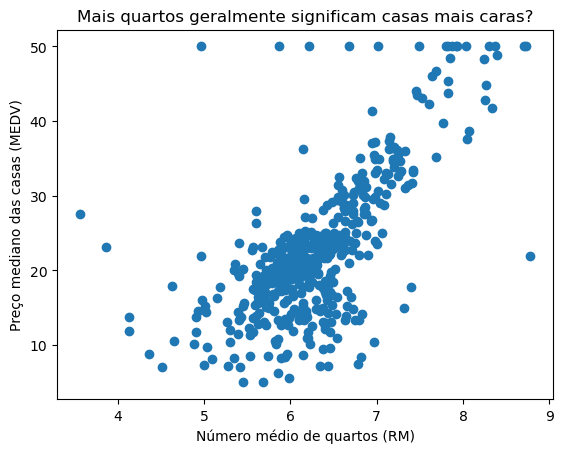

In [ ]:
# 6. Quartos vs preço / Rooms vs price
plt.figure()
plt.scatter(df["RM"], df["MEDV"])
plt.xlabel("Número médio de quartos (RM)")
plt.ylabel("Preço mediano das casas (MEDV)")
plt.title("Mais quartos geralmente significam casas mais caras?")
plt.show()

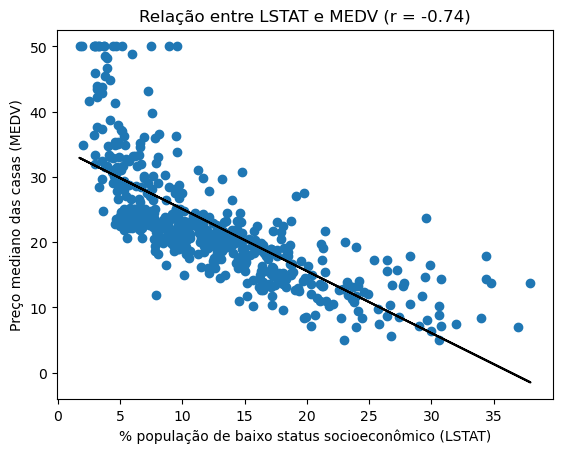

In [ ]:
# 7. LSTAT vs preço / Socioeconomic status vs price
x = df["LSTAT"]
y = df["MEDV"]

# coeficiente de correlação
r = np.corrcoef(x, y)[0,1]

# regressão linear
coef = np.polyfit(x, y, 1)
linha = coef[0]*x + coef[1]

plt.figure()
plt.scatter(x, y)
plt.plot(x, linha, color = "Black")
plt.xlabel("% população de baixo status socioeconômico (LSTAT)")
plt.ylabel("Preço mediano das casas (MEDV)")
plt.title(f"Relação entre LSTAT e MEDV (r = {r:.2f})")

plt.show()

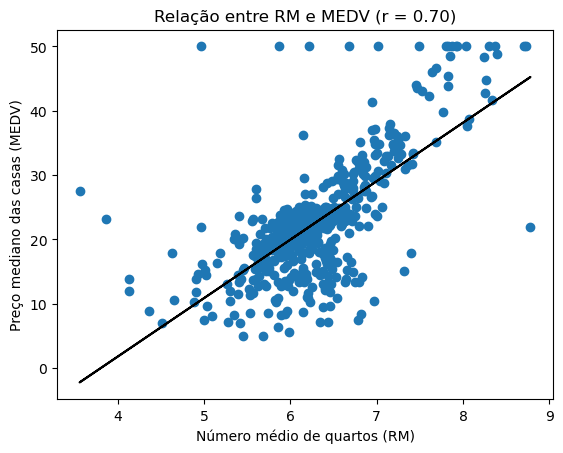

In [ ]:
# 8. Quartos vs preço / Rooms vs price
x = df["RM"]
y = df["MEDV"]

# correlação
r = np.corrcoef(x, y)[0,1]

# regressão linear
coef = np.polyfit(x, y, 1)
linha = coef[0]*x + coef[1]

plt.figure()

plt.scatter(x, y)
plt.plot(x, linha, color = "black")

plt.xlabel("Número médio de quartos (RM)")
plt.ylabel("Preço mediano das casas (MEDV)")
plt.title(f"Relação entre RM e MEDV (r = {r:.2f})")

plt.show()

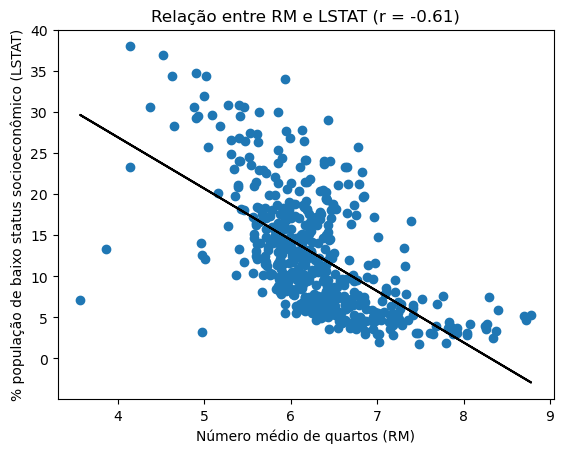

In [ ]:
# 9. Quartos vs status socioeconômico / Rooms vs socioeconomic status
x = df["RM"]
y = df["LSTAT"]

# coeficiente de correlação
r = np.corrcoef(x, y)[0,1]

# regressão linear
coef = np.polyfit(x, y, 1)
linha = coef[0]*x + coef[1]

plt.figure()

plt.scatter(x, y)
plt.plot(x, linha, color = "black")

plt.xlabel("Número médio de quartos (RM)")
plt.ylabel("% população de baixo status socioeconômico (LSTAT)")
plt.title(f"Relação entre RM e LSTAT (r = {r:.2f})")

plt.show()